In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch

# higher-res plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [65]:
from transformers import GPT2Model,GPT2Tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
all_tokens_dict = tokenizer.get_vocab()

# get the Word Token Embeddings matrix
embeddings = gpt2.wte.weight.detach().numpy()

In [8]:
def embed(token):
    token_idx = tokenizer.encode(token)[0]
    token_embeddings = embeddings[token_idx]

    return token_embeddings 

def unembed(token_embeddings):
    logits = token_embeddings @ embeddings.T
    predicted_token_idx = logits.argmax()
    predicted_token = tokenizer.decode([predicted_token_idx])

    return predicted_token

In [4]:
word_list = ["banana", "apple", "cosmic"]
token_list = []

for word in word_list:
    tokens = tokenizer.tokenize(word)
    for token in tokens:
        token_list.append(token)

print(token_list)

['ban', 'ana', 'apple', 'cos', 'mic']


In [15]:
token_embeddings = {}

for token in token_list:
    token_embeddings[token] = embed(token)

print(token_embeddings)

{'ban': array([ 1.02159001e-01, -2.15773936e-02,  7.12690800e-02, -1.32515490e-01,
       -2.28324175e-01,  2.21003339e-01, -3.02861035e-01,  6.82813823e-02,
       -8.47592130e-02,  1.60690874e-01,  1.37523785e-01, -2.32832655e-01,
       -1.73793942e-01, -3.93915772e-02,  1.51153907e-01, -6.24343306e-02,
       -7.58769289e-02, -2.39743039e-01,  2.32308254e-01,  1.72525004e-01,
       -1.70012489e-01, -1.91824228e-01,  3.57261561e-02, -3.73930410e-02,
        8.01892504e-02, -2.07013607e-01,  1.42751500e-01,  1.46784887e-01,
        1.49163129e-02, -1.28268212e-01,  2.96916485e-01,  2.31679026e-02,
       -1.01748027e-01,  1.00018509e-01, -2.27906406e-01, -7.05510080e-02,
       -3.19187105e-01, -3.79528366e-02,  1.28212318e-01, -2.14344800e-01,
       -1.23859145e-01,  2.03097370e-02,  6.90397993e-02,  9.08960849e-02,
       -1.16015941e-01, -6.03222428e-03, -1.14750691e-01, -9.04070493e-03,
        5.67957535e-02, -9.32493284e-02,  2.34713718e-01, -5.65726170e-03,
        1.0924774

dict_keys(['ban', 'ana', 'apple', 'cos', 'mic'])
ban
ana
apple
cos
mic


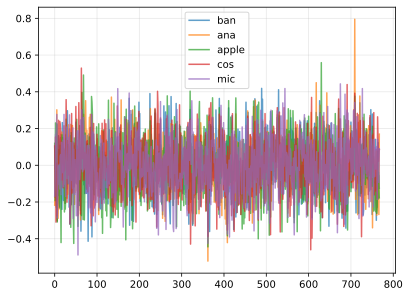

In [23]:
print(token_embeddings.keys())

for token in token_embeddings.keys():
    print(token)
    plt.plot(token_embeddings[token], label=token, alpha=0.7)


plt.legend()
plt.grid(True, alpha=0.3)


In [54]:
from sklearn.metrics.pairwise import cosine_similarity

sk_cs = cosine_similarity([token_embeddings['ban']], [token_embeddings['ana']])[0][0]

def cosine_similarity_local(a, b):

    # Dot product: 1*4 + 2*5 + 3*6 = 32
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)

    dot = sum(a * b)

    # Norms: sqrt(1² + 2² + 3²) = sqrt(14) ≈ 3.74
    norm_a = np.sqrt(sum(a**2))
    norm_b = np.sqrt(sum(b**2))  # sqrt(77) ≈ 8.77

    # Cosine similarity
    cos_sim = dot / (norm_a * norm_b)  # 32 / (3.74 * 8.77) ≈ 0.975

    return cos_sim


local_cs = cosine_similarity_local(token_embeddings['ban'], token_embeddings['ana'])


print(f"Cosine Similarity from SKLearn: {sk_cs}")
print(f"Cosine Similarity from Local: {local_cs}")





Cosine Similarity from SKLearn: 0.2832995057106018
Cosine Similarity from Local: 0.28329955055950956


In [ ]:
# words_with_cos_similarity = {}

# for word_1 in all_tokens_dict:
#     for word_2 in all_tokens_dict:
#         embedding_1 = embed(word_1)
#         embedding_2 = embed(word_2)

#         cos_sim = cosine_similarity_local(embedding_1, embedding_2)
#         words_with_cos_similarity[word_1 + "-" + word_2] = cos_sim




KeyboardInterrupt: 

In [62]:
len(words_with_cos_similarity)

25